In [1]:
import pandas as pd

df = pd.read_parquet("../../data/processed_data/analysis_panel.parquet")
print(f"Shape: {df.shape}")
print(f"\nColumns:\n{df.columns.tolist()}")
print(f"\nFirst 3 rows:\n{df.head(3).to_string()}")

Shape: (16576, 35)

Columns:
['YEAR', 'GEOGRAPHY_CODE', 'GEOGRAPHY_NAME', 'IS8_SECTOR', 'EMPLOYEES', 'BUSINESSES', 'unemployment_rate', 'transport_to_employer', 'drive_to_employer', 'cycle_to_employer', 'broadband', 'coverage_4g', 'gcse_age19', 'apprenticeship_starts', 'apprenticeship_achievements', 'nvq_level3', 'fe_participation', 'housing_net_additions', 'enterprise_birth_rate', 'enterprise_death_rate', 'enterprise_high_growth_rate', 'REGION', 'COUNTY_UA', 'n_universities_feecap_lad', 'lq_bus', 'emp_share', 'lq_emp', 'gd_emp', 'gd_bus', 'n_years_emp', 'n_years_bus', 'related_variety', 'within_sector_diversity', 'size_large_share', 'size_micro_share']

First 3 rows:
   YEAR GEOGRAPHY_CODE GEOGRAPHY_NAME              IS8_SECTOR  EMPLOYEES  BUSINESSES  unemployment_rate  transport_to_employer  drive_to_employer  cycle_to_employer  broadband  coverage_4g  gcse_age19  apprenticeship_starts  apprenticeship_achievements  nvq_level3  fe_participation  housing_net_additions  enterprise_birth

In [2]:
import pandas as pd

RAW = "/Users/francosebastiani/Documents/GitHub/Economic_Observatory/data/raw_data"

df = pd.read_parquet(f"{RAW}/employee_counts/Employee_counts_IS8_LADs.parquet")

print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nDtypes:\n{df.dtypes}")
print(f"\nYear range: {df['YEAR'].min()} – {df['YEAR'].max()}")
print(f"Unique LADs: {df['GEOGRAPHY_CODE'].nunique()}")
print(f"Unique INDUSTRY_CODEs: {df['INDUSTRY_CODE'].nunique()}")
print(f"Unique IS8_SECTORs: {df['IS8_SECTOR'].unique().tolist()}")
print(f"Unique FRONTIER_SECTORs: {df['FRONTIER_SECTOR'].dropna().unique().tolist()}")
print(f"\nSample rows (one per IS8 sector):")
print(df.groupby('IS8_SECTOR').first().reset_index()[['YEAR','GEOGRAPHY_CODE','GEOGRAPHY_NAME','IS8_SECTOR','FRONTIER_SECTOR','INDUSTRY_CODE','OBS_VALUE']].to_string(index=False))

Shape: (312400, 8)

Columns: ['YEAR', 'GEOGRAPHY_CODE', 'GEOGRAPHY_NAME', 'GEOGRAPHY_TYPE', 'IS8_SECTOR', 'FRONTIER_SECTOR', 'INDUSTRY_CODE', 'OBS_VALUE']

Dtypes:
YEAR               int16
GEOGRAPHY_CODE       str
GEOGRAPHY_NAME       str
GEOGRAPHY_TYPE       str
IS8_SECTOR           str
FRONTIER_SECTOR      str
INDUSTRY_CODE        str
OBS_VALUE          Int64
dtype: object

Year range: 2015 – 2024
Unique LADs: 355
Unique INDUSTRY_CODEs: 85
Unique IS8_SECTORs: ['Advanced manufacturing', 'Creative Industries', 'Defence sector', 'Digital and Technology', 'Financial Services', 'Life Sciences', 'Professional and Business Services', 'Total']
Unique FRONTIER_SECTORs: ['Aerospace manufacturing', 'Agritech', 'Automotive manufacturing', 'Batteries', 'Advertising and marketing', 'Film and TV', 'Music, peforming, and visual arts', 'Video games', 'Asset management and wholesale services', 'Capital markets and retail investment', 'Insurance and reinsurance markets', 'Accounting, audit and tax cons

In [3]:
import pandas as pd

RAW = "/Users/francosebastiani/Documents/GitHub/Economic_Observatory/data/raw_data"

df = pd.read_parquet(f"{RAW}/employee_counts/Employee_counts_IS8_LADs.parquet")

# Filter to 2023, LAD level, frontier sectors only, non-zero employment
lad_type = "local authorities: district / unitary (as of April 2023)"
frontier = (df[
    (df["YEAR"] == 2023) &
    (df["GEOGRAPHY_TYPE"] == lad_type) &
    (df["FRONTIER_SECTOR"].notna()) &
    (df["OBS_VALUE"] > 0)
]).copy()

# Aggregate by LAD × frontier sector
agg = frontier.groupby(["FRONTIER_SECTOR", "IS8_SECTOR"])["GEOGRAPHY_CODE"].nunique().reset_index()
agg.columns = ["frontier_sector", "IS8_sector", "n_lads_with_employment"]
agg = agg.sort_values("n_lads_with_employment", ascending=False)

print("=== Frontier sector presence in 2023 (LADs with non-zero employment) ===")
print(f"Total LADs in dataset: {df[df['GEOGRAPHY_TYPE']==lad_type]['GEOGRAPHY_CODE'].nunique()}")
print()
print(agg.to_string(index=False))

=== Frontier sector presence in 2023 (LADs with non-zero employment) ===
Total LADs in dataset: 350

                        frontier_sector                         IS8_sector  n_lads_with_employment
  Accounting, audit and tax consultancy Professional and Business Services                     349
              Advertising and marketing                Creative Industries                     349
Asset management and wholesale services                 Financial Services                     349
                 Management consultancy Professional and Business Services                     349
      Music, peforming, and visual arts                Creative Industries                     349
  Capital markets and retail investment                 Financial Services                     349
                         Legal services Professional and Business Services                     349
                            Film and TV                Creative Industries                     347
      In

In [4]:
import pandas as pd

RAW = "/Users/francosebastiani/Documents/GitHub/Economic_Observatory/data/raw_data"

df = pd.read_parquet(f"{RAW}/employee_counts/Employee_counts_IS8_LADs.parquet")

SY_LADS = {
    "E08000019": "Sheffield",
    "E08000017": "Doncaster",
    "E08000018": "Rotherham",
    "E08000016": "Barnsley"
}

lad_type = "local authorities: district / unitary (as of April 2023)"

sy = (df[
    (df["YEAR"] == 2023) &
    (df["GEOGRAPHY_TYPE"] == lad_type) &
    (df["GEOGRAPHY_CODE"].isin(SY_LADS)) &
    (df["FRONTIER_SECTOR"].notna())
]).copy()

sy["LAD"] = sy["GEOGRAPHY_CODE"].map(SY_LADS)

# Aggregate employment by LAD × frontier sector
agg = (sy.groupby(["FRONTIER_SECTOR", "IS8_SECTOR", "LAD"])["OBS_VALUE"]
         .sum()
         .reset_index()
         .pivot(index=["FRONTIER_SECTOR", "IS8_SECTOR"], columns="LAD", values="OBS_VALUE")
         .reset_index()
         .sort_values("FRONTIER_SECTOR"))

agg["SY_total"] = agg[["Sheffield", "Doncaster", "Rotherham", "Barnsley"]].sum(axis=1)
agg = agg.sort_values("SY_total", ascending=False)

print("=== SY frontier sector employment (2023) ===")
print(agg.to_string(index=False))

=== SY frontier sector employment (2023) ===
                        FRONTIER_SECTOR                         IS8_SECTOR  Barnsley  Doncaster  Rotherham  Sheffield  SY_total
  Capital markets and retail investment                 Financial Services       480        775       1190       4820      7265
                         Legal services Professional and Business Services       450        700        300       4500      5950
Asset management and wholesale services                 Financial Services       610       1760        500       2600      5470
                 Management consultancy Professional and Business Services       800        700        700       3000      5200
  Accounting, audit and tax consultancy Professional and Business Services       700        600        350       2000      3650
      Insurance and reinsurance markets                 Financial Services        75        650        185        660      1570
               Automotive manufacturing             Advance

In [5]:
import pandas as pd

RAW = "/Users/francosebastiani/Documents/GitHub/Economic_Observatory/data/raw_data"

df = pd.read_parquet(f"{RAW}/employee_counts/Employee_counts_IS8_LADs.parquet")

SY_LADS = {
    "E08000019": "Sheffield",
    "E08000017": "Doncaster",
    "E08000018": "Rotherham",
    "E08000016": "Barnsley"
}

lad_type  = "local authorities: district / unitary (as of April 2023)"
benchmark = "Great Britain"
year      = 2023

# --- LAD total employment (from Total row) ---
lad_total = (df[
    (df["YEAR"] == year) &
    (df["GEOGRAPHY_TYPE"] == lad_type) &
    (df["IS8_SECTOR"] == "Total") &
    (df["GEOGRAPHY_CODE"].isin(SY_LADS))
].groupby("GEOGRAPHY_CODE")["OBS_VALUE"].sum()
  .rename("LAD_TOTAL"))

# --- National total employment ---
nat_total = df[
    (df["YEAR"] == year) &
    (df["GEOGRAPHY_NAME"] == benchmark) &
    (df["IS8_SECTOR"] == "Total")
]["OBS_VALUE"].sum()

# --- LAD frontier employment ---
lad_frontier = (df[
    (df["YEAR"] == year) &
    (df["GEOGRAPHY_TYPE"] == lad_type) &
    (df["GEOGRAPHY_CODE"].isin(SY_LADS)) &
    (df["FRONTIER_SECTOR"].notna())
].groupby(["GEOGRAPHY_CODE", "FRONTIER_SECTOR"])["OBS_VALUE"].sum()
  .reset_index()
  .rename(columns={"OBS_VALUE": "LAD_FRONTIER_EMP"}))

# --- National frontier employment ---
nat_frontier = (df[
    (df["YEAR"] == year) &
    (df["GEOGRAPHY_NAME"] == benchmark) &
    (df["FRONTIER_SECTOR"].notna())
].groupby("FRONTIER_SECTOR")["OBS_VALUE"].sum()
  .reset_index()
  .rename(columns={"OBS_VALUE": "NAT_FRONTIER_EMP"}))

# --- Compute LQ ---
lad_frontier = lad_frontier.merge(lad_total, on="GEOGRAPHY_CODE")
lad_frontier = lad_frontier.merge(nat_frontier, on="FRONTIER_SECTOR")
lad_frontier["NAT_TOTAL"] = nat_total
lad_frontier["lq_frontier"] = (
    (lad_frontier["LAD_FRONTIER_EMP"] / lad_frontier["LAD_TOTAL"]) /
    (lad_frontier["NAT_FRONTIER_EMP"] / lad_frontier["NAT_TOTAL"])
)
lad_frontier["LAD"] = lad_frontier["GEOGRAPHY_CODE"].map(SY_LADS)

# Pivot for readability
out = (lad_frontier.pivot(index="FRONTIER_SECTOR", columns="LAD", values="lq_frontier")
                   .reset_index()
                   .sort_values("Sheffield", ascending=False))

print("=== SY frontier sector LQ (2023) ===")
print(out.to_string(index=False))

=== SY frontier sector LQ (2023) ===
                        FRONTIER_SECTOR  Barnsley  Doncaster  Rotherham  Sheffield
                         Legal services   0.52155   0.536087   0.312391   1.679411
                               Agritech   1.54478   4.253136   0.925271   1.658085
  Capital markets and retail investment  0.400036   0.426789   0.891042   1.293498
      Music, peforming, and visual arts  0.324995   0.195226   0.106179   0.903792
                 Management consultancy  0.553472   0.320006   0.435108   0.668326
              Advertising and marketing  0.300374    0.13232   0.287862   0.606122
Asset management and wholesale services  0.401963   0.766342   0.296019   0.551685
                            Video games  0.136018        0.0   0.305514   0.547481
  Accounting, audit and tax consultancy  0.536838   0.304054   0.241161   0.493898
      Insurance and reinsurance markets  0.137436   0.787057   0.304582   0.389443
                Aerospace manufacturing       0.0 

In [6]:
import pandas as pd
import numpy as np
from scipy import stats

RAW = "/Users/francosebastiani/Documents/GitHub/Economic_Observatory/data/raw_data"

df = pd.read_parquet(f"{RAW}/employee_counts/Employee_counts_IS8_LADs.parquet")

SY_LADS = {
    "E08000019": "Sheffield",
    "E08000017": "Doncaster",
    "E08000018": "Rotherham",
    "E08000016": "Barnsley"
}

lad_type  = "local authorities: district / unitary (as of April 2023)"
benchmark = "Great Britain"
y0, y1    = 2016, 2023

def ols_slope(years, values):
    mask = (values > 0) & np.isfinite(values)
    x, y = years[mask], values[mask]
    if len(x) < 4:
        return np.nan
    slope, _, _, _, _ = stats.linregress(x, np.log(y))
    return slope

# --- LAD frontier employment time series ---
lad_ts = (df[
    (df["YEAR"] >= y0) & (df["YEAR"] <= y1) &
    (df["GEOGRAPHY_TYPE"] == lad_type) &
    (df["GEOGRAPHY_CODE"].isin(SY_LADS)) &
    (df["FRONTIER_SECTOR"].notna())
].groupby(["GEOGRAPHY_CODE", "FRONTIER_SECTOR", "YEAR"])["OBS_VALUE"]
  .sum().reset_index())

# --- National frontier employment time series ---
nat_ts = (df[
    (df["YEAR"] >= y0) & (df["YEAR"] <= y1) &
    (df["GEOGRAPHY_NAME"] == benchmark) &
    (df["FRONTIER_SECTOR"].notna())
].groupby(["FRONTIER_SECTOR", "YEAR"])["OBS_VALUE"]
  .sum().reset_index())

# --- National slopes ---
nat_slopes = {}
for sector, grp in nat_ts.groupby("FRONTIER_SECTOR"):
    grp = grp.sort_values("YEAR")
    nat_slopes[sector] = ols_slope(grp["YEAR"].values, grp["OBS_VALUE"].values.astype(float))

# --- LAD slopes and GD ---
records = []
for (geo, sector), grp in lad_ts.groupby(["GEOGRAPHY_CODE", "FRONTIER_SECTOR"]):
    grp = grp.sort_values("YEAR")
    beta_lad = ols_slope(grp["YEAR"].values, grp["OBS_VALUE"].values.astype(float))
    beta_nat = nat_slopes.get(sector, np.nan)
    gd = beta_lad - beta_nat if (not np.isnan(beta_nat) and beta_nat != 0) else np.nan
    records.append({
        "GEOGRAPHY_CODE": geo,
        "LAD": SY_LADS[geo],
        "FRONTIER_SECTOR": sector,
        "beta_lad": round(beta_lad, 4) if not np.isnan(beta_lad) else np.nan,
        "beta_nat": round(beta_nat, 4) if not np.isnan(beta_nat) else np.nan,
        "gd_emp": round(gd, 4) if not np.isnan(gd) else np.nan
    })

gd = pd.DataFrame(records)

# Pivot GD for readability
out = (gd.pivot(index="FRONTIER_SECTOR", columns="LAD", values="gd_emp")
         .reset_index()
         .sort_values("Sheffield", ascending=False))

print("=== SY frontier sector GD (2016–2023) ===")
print("Positive = growing faster than national trend")
print()
print(out.to_string(index=False))

# Also show national slopes for context
print("\n=== National growth slopes by frontier sector ===")
nat_df = pd.DataFrame([{"FRONTIER_SECTOR": k, "beta_national": round(v,4)} 
                        for k,v in nat_slopes.items()]).sort_values("beta_national", ascending=False)
print(nat_df.to_string(index=False))

=== SY frontier sector GD (2016–2023) ===
Positive = growing faster than national trend

                        FRONTIER_SECTOR  Barnsley  Doncaster  Rotherham  Sheffield
                Aerospace manufacturing       NaN    -0.2968     0.2908     0.3158
                               Agritech    0.1029     0.0898     0.2941     0.0884
              Advertising and marketing   -0.0206    -0.0350     0.0335     0.0472
                            Video games   -0.1279        NaN     0.1094     0.0307
                         Legal services    0.0348    -0.0273    -0.0430     0.0048
  Accounting, audit and tax consultancy    0.1143     0.0516     0.0181    -0.0001
  Capital markets and retail investment   -0.0577     0.0981    -0.0000    -0.0116
      Music, peforming, and visual arts    0.0028    -0.0516    -0.1769    -0.0142
Asset management and wholesale services    0.0765     0.0067     0.0474    -0.0357
               Automotive manufacturing   -0.0744     0.0700    -0.0682    -0.057

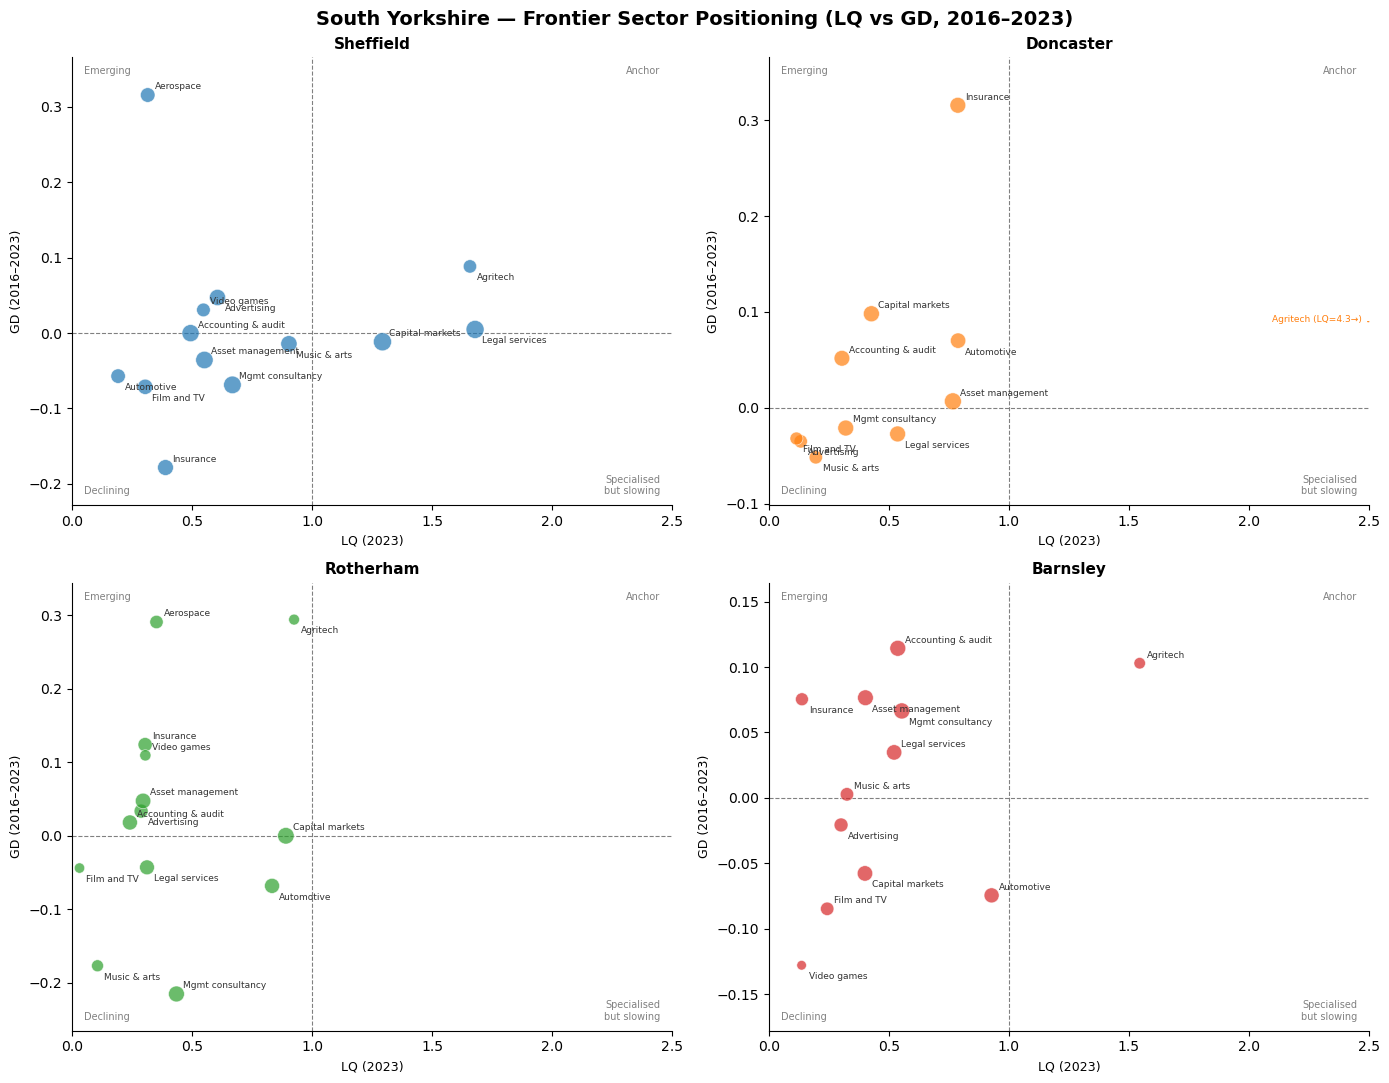

✅ Saved


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats

RAW = "/Users/francosebastiani/Documents/GitHub/Economic_Observatory/data/raw_data"
OUT = "/Users/francosebastiani/Documents/GitHub/Economic_Observatory/output/graphs/franco"

df = pd.read_parquet(f"{RAW}/employee_counts/Employee_counts_IS8_LADs.parquet")

SY_LADS = {
    "E08000019": "Sheffield",
    "E08000017": "Doncaster",
    "E08000018": "Rotherham",
    "E08000016": "Barnsley"
}
LAD_COLORS = {
    "Sheffield":  "#1f77b4",
    "Doncaster":  "#ff7f0e",
    "Rotherham":  "#2ca02c",
    "Barnsley":   "#d62728"
}

lad_type  = "local authorities: district / unitary (as of April 2023)"
benchmark = "Great Britain"
y0, y1    = 2016, 2023

def ols_slope(years, values):
    mask = (values > 0) & np.isfinite(values)
    x, y = years[mask], values[mask]
    if len(x) < 4:
        return np.nan
    slope, _, _, _, _ = stats.linregress(x, np.log(y))
    return slope

# --- LQ (2023) ---
lad_total = (df[
    (df["YEAR"] == y1) & (df["GEOGRAPHY_TYPE"] == lad_type) &
    (df["IS8_SECTOR"] == "Total") & (df["GEOGRAPHY_CODE"].isin(SY_LADS))
].groupby("GEOGRAPHY_CODE")["OBS_VALUE"].sum().rename("LAD_TOTAL"))

nat_total = df[
    (df["YEAR"] == y1) & (df["GEOGRAPHY_NAME"] == benchmark) &
    (df["IS8_SECTOR"] == "Total")
]["OBS_VALUE"].sum()

lad_frontier_emp = (df[
    (df["YEAR"] == y1) & (df["GEOGRAPHY_TYPE"] == lad_type) &
    (df["GEOGRAPHY_CODE"].isin(SY_LADS)) & (df["FRONTIER_SECTOR"].notna())
].groupby(["GEOGRAPHY_CODE","FRONTIER_SECTOR"])["OBS_VALUE"].sum().reset_index())

nat_frontier_emp = (df[
    (df["YEAR"] == y1) & (df["GEOGRAPHY_NAME"] == benchmark) &
    (df["FRONTIER_SECTOR"].notna())
].groupby("FRONTIER_SECTOR")["OBS_VALUE"].sum().reset_index()
  .rename(columns={"OBS_VALUE":"NAT_FRONTIER_EMP"}))

lq = lad_frontier_emp.merge(lad_total, on="GEOGRAPHY_CODE")
lq = lq.merge(nat_frontier_emp, on="FRONTIER_SECTOR")
lq["NAT_TOTAL"] = nat_total
lq["lq"] = (lq["OBS_VALUE"] / lq["LAD_TOTAL"]) / (lq["NAT_FRONTIER_EMP"] / lq["NAT_TOTAL"])
lq["LAD"] = lq["GEOGRAPHY_CODE"].map(SY_LADS)

# --- GD ---
lad_ts = (df[
    (df["YEAR"] >= y0) & (df["YEAR"] <= y1) &
    (df["GEOGRAPHY_TYPE"] == lad_type) &
    (df["GEOGRAPHY_CODE"].isin(SY_LADS)) & (df["FRONTIER_SECTOR"].notna())
].groupby(["GEOGRAPHY_CODE","FRONTIER_SECTOR","YEAR"])["OBS_VALUE"].sum().reset_index())

nat_ts = (df[
    (df["YEAR"] >= y0) & (df["YEAR"] <= y1) &
    (df["GEOGRAPHY_NAME"] == benchmark) & (df["FRONTIER_SECTOR"].notna())
].groupby(["FRONTIER_SECTOR","YEAR"])["OBS_VALUE"].sum().reset_index())

nat_slopes = {}
for sector, grp in nat_ts.groupby("FRONTIER_SECTOR"):
    nat_slopes[sector] = ols_slope(grp.sort_values("YEAR")["YEAR"].values,
                                   grp.sort_values("YEAR")["OBS_VALUE"].values.astype(float))

gd_records = []
for (geo, sector), grp in lad_ts.groupby(["GEOGRAPHY_CODE","FRONTIER_SECTOR"]):
    beta_lad = ols_slope(grp.sort_values("YEAR")["YEAR"].values,
                         grp.sort_values("YEAR")["OBS_VALUE"].values.astype(float))
    beta_nat = nat_slopes.get(sector, np.nan)
    gd = beta_lad - beta_nat if (not np.isnan(beta_nat) and beta_nat != 0) else np.nan
    gd_records.append({"GEOGRAPHY_CODE": geo, "FRONTIER_SECTOR": sector, "gd": gd})

gd_df = pd.DataFrame(gd_records)
gd_df["LAD"] = gd_df["GEOGRAPHY_CODE"].map(SY_LADS)

# --- Merge ---
merged = lq[["LAD","FRONTIER_SECTOR","lq","OBS_VALUE"]].merge(
    gd_df[["LAD","FRONTIER_SECTOR","gd"]], on=["LAD","FRONTIER_SECTOR"])
merged = merged.dropna(subset=["lq","gd"])
merged = merged[merged["OBS_VALUE"] > 0]

# Shorten labels for readability
label_map = {
    "Accounting, audit and tax consultancy": "Accounting & audit",
    "Advertising and marketing":             "Advertising",
    "Asset management and wholesale services": "Asset management",
    "Capital markets and retail investment": "Capital markets",
    "Insurance and reinsurance markets":     "Insurance",
    "Music, peforming, and visual arts":     "Music & arts",
    "Automotive manufacturing":              "Automotive",
    "Aerospace manufacturing":               "Aerospace",
    "Management consultancy":                "Mgmt consultancy",
    "Professional and Business Services":    "PBS",
}
merged["label"] = merged["FRONTIER_SECTOR"].replace(label_map)

# Cap x-axis at 2.5, annotate outliers
X_CAP = 2.5

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle("South Yorkshire — Frontier Sector Positioning (LQ vs GD, 2016–2023)",
             fontsize=14, fontweight="bold")

for ax, (lad_name, color) in zip(axes.flat, LAD_COLORS.items()):
    sub = merged[merged["LAD"] == lad_name].copy()
    outliers = sub[sub["lq"] > X_CAP]
    sub_plot  = sub[sub["lq"] <= X_CAP]

    ax.axvline(1, color="grey", linewidth=0.8, linestyle="--", zorder=1)
    ax.axhline(0, color="grey", linewidth=0.8, linestyle="--", zorder=1)

    # Bubble size: log scale to prevent dominance
    sizes = np.log1p(sub_plot["OBS_VALUE"]) * 20

    ax.scatter(sub_plot["lq"], sub_plot["gd"], s=sizes,
               color=color, alpha=0.7, edgecolors="white", linewidths=0.5, zorder=3)

    # Labels with simple offset — stagger alternating points
    for i, (_, row) in enumerate(sub_plot.iterrows()):
        offset = (5, 4) if i % 2 == 0 else (5, -10)
        ax.annotate(row["label"], xy=(row["lq"], row["gd"]),
                    xytext=offset, textcoords="offset points",
                    fontsize=6.5, color="#333333")

    # Annotate outliers as arrows on right edge
    for _, row in outliers.iterrows():
        ax.annotate(f"{row['label']} (LQ={row['lq']:.1f}→)",
                    xy=(X_CAP, row["gd"]),
                    xytext=(-5, 0), textcoords="offset points",
                    fontsize=6.5, color=color, ha="right",
                    arrowprops=dict(arrowstyle="-", color=color, lw=0.8))

    ax.set_xlim(0, X_CAP)
    ypad = 0.05
    ymin = sub_plot["gd"].min() - ypad
    ymax = sub_plot["gd"].max() + ypad
    ax.set_ylim(ymin, ymax)

    # Quadrant labels — fixed relative positions
    ax.text(0.02, 0.98, "Emerging", transform=ax.transAxes,
            fontsize=7, color="grey", va="top")
    ax.text(0.98, 0.98, "Anchor", transform=ax.transAxes,
            fontsize=7, color="grey", va="top", ha="right")
    ax.text(0.02, 0.02, "Declining", transform=ax.transAxes,
            fontsize=7, color="grey", va="bottom")
    ax.text(0.98, 0.02, "Specialised\nbut slowing", transform=ax.transAxes,
            fontsize=7, color="grey", va="bottom", ha="right")

    ax.set_title(lad_name, fontweight="bold", fontsize=11)
    ax.set_xlabel("LQ (2023)", fontsize=9)
    ax.set_ylabel("GD (2016–2023)", fontsize=9)
    ax.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig(f"{OUT}/sy_frontier_quadrant.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved")